In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from bayspecdec.spectrum_gen import *
import bayspecdec as bsd

from functools import partial

In [2]:
import jupyter_black

jupyter_black.load()

In [3]:
Array = np.ndarray[tuple[int], np.dtype(np.float32)]

In [4]:
BIN_SIZE: float = 1e-1
MIN: float = 0
MAX: float = 12

In [5]:
DET_AX: Array = np.arange(MIN, MAX, BIN_SIZE)
PEAK: Array = np.zeros_like(DET_AX)
PEAK += lorentzian(DET_AX, 6, 0.5, 1)

In [48]:
SIGNAL: Array = np.zeros_like(DET_AX)
SIGNAL[bin_idx(DET_AX, 3)] += 1
SIGNAL[bin_idx(DET_AX, 6)] += 2
SIGNAL[bin_idx(DET_AX, 10)] += 2
# SIGNAL[bin_idx(DET_AX, 6)] += 2

BLURRED: Array = sp.signal.convolve(SIGNAL, PEAK, mode="full")[
    len(DET_AX) // 2 : -len(DET_AX) // 2 + 1
]

# y = draw_spectrum(BLURRED, dose=1_000_000).astype(np.float64)
# y /= y.max()

y = np.random.normal(loc=BLURRED, scale=0.01)

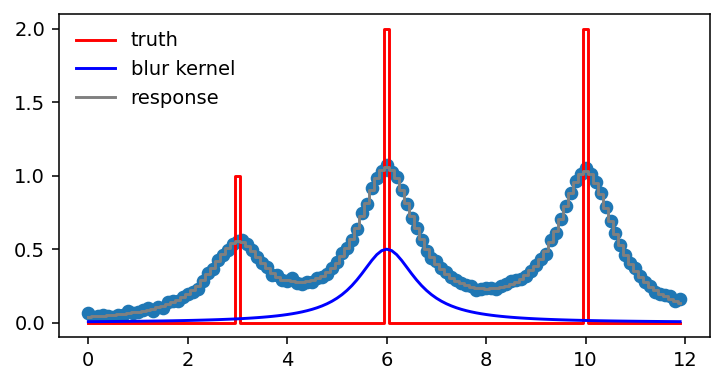

In [49]:
plt.step(DET_AX, SIGNAL, where="mid", label="truth", color="red")
plt.plot(DET_AX, PEAK, label="blur kernel", color="blue")
plt.step(DET_AX, BLURRED, where="mid", label="response", color="gray")
plt.scatter(DET_AX, y)
fig = plt.gcf()
fig.set_size_inches(6, 3)
fig.set_dpi(140)
plt.legend(frameon=False)

In [50]:
print(f"σ^2: {np.nanstd(BLURRED - y) ** 2:.2e}")

σ^2: 1.05e-04


In [51]:
from typing import Iterable


class BlurKernel:
    name: str = "BlurKernel"
    n_parameters_per_basis: int = 1

    def evaluate(self, x: Array, params: Iterable[Array]) -> Array:
        (μ,) = params
        evals = []
        for μi in μ:
            peak = lorentzian(x, μi, 0.5, 1)
            peak /= peak.max()
            evals.append(peak)
        return np.stack(evals)

In [52]:
from numba.experimental.jitclass.decorators import jitclass


class Parameterization:
    def __init__(self, K: int):
        self.K = K
        self.ndim = 2 * K

    def pack(self, structured: tuple[Array, Array, Array]) -> Array:
        I, μ = structured
        θ = np.empty(self.ndim)
        θ[: self.K] = I
        θ[self.K : 2 * self.K] = μ
        # θ[2 * self.K :] = σ
        return θ

    def unpack(self, θ: Array) -> tuple[Array, Array, Array]:
        I: Array = θ[..., : self.K]
        μ: Array = θ[..., self.K : 2 * self.K]
        # σ: Array = θ[..., 2 * self.K :]
        return (I, μ)  # , σ)

    def to_z(self, θ: Array) -> Array:
        z = θ.copy()
        # z[..., : self.K] = np.log(z[..., : self.K])
        return z

    def from_z(self, z: Array) -> Array:
        θ = z.copy()
        # θ[..., : self.K] = np.exp(θ[..., : self.K])
        return θ

    def log_jacobian(self, θ: Array) -> float:
        return 1
        I, μ, σ = self.unpack(θ)
        return float(np.sum(np.log(I)) + np.sum(np.log(θ)))

In [53]:
class LorentzPrior:
    def __init__(self, amplitudes, centers):  # , widths):
        self.amplitudes = amplitudes
        self.centers = centers
        # self.widths = widths

    def sample(self, rng, parameterization) -> Array:
        K: int = parameterization.K
        I: Array = self.amplitudes.sample(rng, K)
        μ: Array = self.centers.sample(rng, K)
        # σ: Array = self.widths.sample(rng, K)
        # print(f"I: {I}, μ: {μ}, σ: {σ}")
        # for Ii, μi, σi in zip(I, μ, σ):
        #     plt.plot(lorentzian(DET_AX, μi, σi, Ii))
        # plt.show()
        return parameterization.pack((I, μ))

    def log_prob(self, θ, parameterization) -> float:
        I, μ = parameterization.unpack(θ)
        lp_I = np.sum(self.amplitudes.log_prob(I))
        lp_μ = np.sum(self.centers.log_prob(μ))
        # lp_σ = np.sum(self.widths.log_prob(σ))
        return float(lp_I + lp_μ)  # + lp_σ)

In [73]:
lorentz_prior = LorentzPrior(
    amplitudes=bsd.UniformPrior(0.2, 1.2),
    centers=bsd.UniformPrior(1, 11),
    # widths=bsd.GammaPrior(5, 8),
)

In [74]:
betas = bsd.beta_schedule(64)

In [75]:
def spectral_model_builder(K: int) -> bsd.SpectralModel:
    return bsd.SpectralModel(
        x=DET_AX,
        y=y,
        basis=BlurKernel(),
        prior=lorentz_prior,
        likelihood=bsd.GaussianNoise(sigma2=1e-4),
        parameterization=Parameterization(K=K),
    )


def sampler_builder(model, rng):
    K = model.parameterization.K
    return bsd.ParallelTempering(
        model=model,
        betas=betas,
        rng=np.random.default_rng(),
        kernel_factory=lambda model, beta, rng: bsd.hmc_kernel_factory(
            model, beta, rng
        ),
    )

In [76]:
runs = bsd.select_model_size(
    model_factory=spectral_model_builder,
    K_values=[2, 3, 4],
    sampler_factory=sampler_builder,
    burn_in=1_000,
    samples=1_000,
    swap_every=10,
    # store_state_trace=True,
)

100%|█████████████████████████████████████████████████████████████████| 1000/1000 [04:47<00:00,  3.48it/s]


 0 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-6162399060127728729040922137014059700928078626793370945328371242003749227886021830017657172460001271218176.0000 weight-ESS=1.0/1000
 1 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2349 weight-ESS=938.6/1000
 2 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2288 weight-ESS=939.6/1000
 3 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2382 weight-ESS=932.5/1000
 4 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2323 weight-ESS=939.3/1000
 5 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2096 weight-ESS=942.6/1000
 6 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2173 weight-ESS=947.6/1000
 7 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2423 weight-ESS=944.4/1000
 8 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2576 weight-ESS=929.2/1000
 9 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2585 weight-ESS=934.0/1000
10 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2744 weight-ESS=935.0/1000
11 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.3096 weight-ESS=925.1/1000
12 beta=0.0000->0.000

100%|█████████████████████████████████████████████████████████████████| 1000/1000 [06:10<00:00,  2.70it/s]


 0 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-7185050373281730479930542688376209791452471576839500197904158089233824320472763476755162932937796616192.0000 weight-ESS=1.0/1000
 1 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2123 weight-ESS=946.1/1000
 2 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2364 weight-ESS=941.6/1000
 3 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2690 weight-ESS=924.3/1000
 4 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2891 weight-ESS=922.4/1000
 5 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2774 weight-ESS=922.0/1000
 6 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2711 weight-ESS=928.1/1000
 7 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2634 weight-ESS=932.6/1000
 8 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.3029 weight-ESS=922.4/1000
 9 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2905 weight-ESS=934.0/1000
10 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.3112 weight-ESS=935.9/1000
11 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.3950 weight-ESS=888.5/1000
12 beta=0.0000->0.0000 Δ

100%|█████████████████████████████████████████████████████████████████| 1000/1000 [09:07<00:00,  1.83it/s]

 0 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-1431656845531917926554249471655154137966988095646935211298814053754299413049119935792534370222302415552512.0000 weight-ESS=1.0/1000
 1 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2157 weight-ESS=942.2/1000
 2 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2157 weight-ESS=946.0/1000
 3 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2339 weight-ESS=943.6/1000
 4 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2625 weight-ESS=933.9/1000
 5 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.2655 weight-ESS=925.9/1000
 6 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.3048 weight-ESS=913.5/1000
 7 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.3123 weight-ESS=919.2/1000
 8 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.3171 weight-ESS=916.0/1000
 9 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.3117 weight-ESS=922.5/1000
10 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.3292 weight-ESS=916.5/1000
11 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.3365 weight-ESS=906.8/1000
12 beta=0.0000->0.000

In [77]:
evidence = [-r.evidence.log_z for r in runs]
best_run = np.argmin(evidence)
K_values = [r.K for r in runs]

optimal_K = K_values[best_run]
print(f"K: {optimal_K}, -logZ: {evidence[best_run]}")

K: 3, -logZ: 7.18505037328173e+102


In [78]:
print(evidence)

[6.162399060127729e+105, 7.18505037328173e+102, 1.431656845531918e+105]


In [79]:
posteriors = runs[best_run].exchange_result.samples_by_temperature[-1]

μ: 3.009±0.003;
μ: 5.998±0.002;
μ: 10.004±0.002;


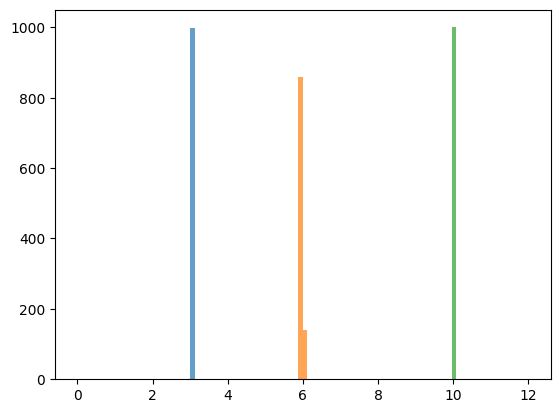

In [80]:
I, μ = Parameterization(K=optimal_K).unpack(
    runs[best_run].exchange_result.samples_by_temperature[-1]
)
key = np.argsort(μ, axis=1)

I = np.take_along_axis(I, axis=1, indices=key)
μ = np.take_along_axis(μ, axis=1, indices=key)
# σ = np.take_along_axis(σ, axis=1, indices=key)

for i in range(optimal_K):
    plt.hist(μ[:, i], range=(0, 12), bins=100, alpha=0.7)
    print(
        f"μ: {np.nanmean(μ[:, i]):.3f}±{np.nanstd(μ[:, i]):.3f};"  # σ: {np.nanmean(σ[:, i]):.3f}±{np.nanstd(σ[:, i]):.2f}"
    )

center: 3.01, height: 0.48
center: 6.00, height: 1.00
center: 10.00, height: 1.00


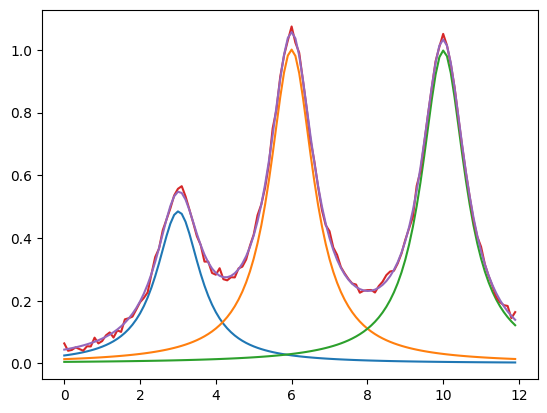

In [81]:
evals = []
for i in range(optimal_K):
    Ii = np.nanmean(I[:, i])
    μi = np.nanmean(μ[:, i])
    # σi = np.nanmean(σ[:, i])
    print(f"center: {μi:.2f}, height: {Ii:.2f}")
    trace = lorentzian(DET_AX, μi, 0.5, 1)
    trace /= trace.max()
    trace *= Ii
    evals.append(trace)
    plt.plot(DET_AX, trace)

plt.plot(DET_AX, y)
plt.plot(DET_AX, np.stack(evals).sum(axis=0))

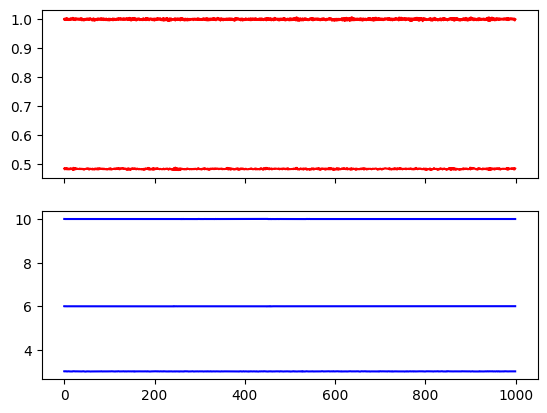

In [82]:
result = runs[best_run].exchange_result
states = result.samples_by_temperature[-1]
I, μ = Parameterization(K=optimal_K).unpack(states)
key = np.argsort(μ, axis=1)

I = np.take_along_axis(I, indices=key, axis=1)
μ = np.take_along_axis(μ, indices=key, axis=1)
# σ = np.take_along_axis(σ, indices=key, axis=1)

fig, (tax, bax) = plt.subplots(nrows=2, sharex=True)

tax.plot(
    I,
    label="amplitudes",
    color="red",
)
bax.plot(
    μ,
    label="centers",
    color="blue",
)

In [83]:
samples = result.samples_by_temperature[-1]

recomputed = np.array(
    [spectral_model_builder(optimal_K).log_likelihood(theta) for theta in samples]
)
stored = np.asarray(result.log_likelihood_trace_by_temperature[-1])

difference = np.max(np.abs(stored - recomputed))
print(difference)

0.0


Text(0.5, 0, '$\\beta_l$')

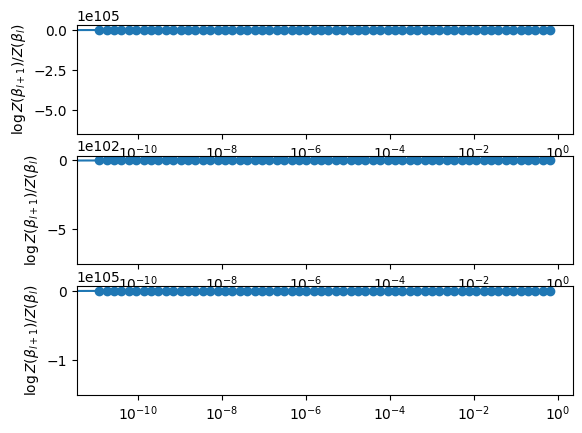

In [84]:
fig, axes = plt.subplots(nrows=3)

for i, run in enumerate(runs):
    res = run.exchange_result

    axes[i].plot(
        res.beta[:-1],
        run.evidence.log_ratios,
        marker="o",
    )
    axes[i].semilogx()
    axes[i].set_ylabel(r"$\log Z(\beta_{l+1})/Z(\beta_l)$")
axes[0].set_xlabel(r"$\beta_l$")

Text(0.5, 0, '$\\beta_l$')

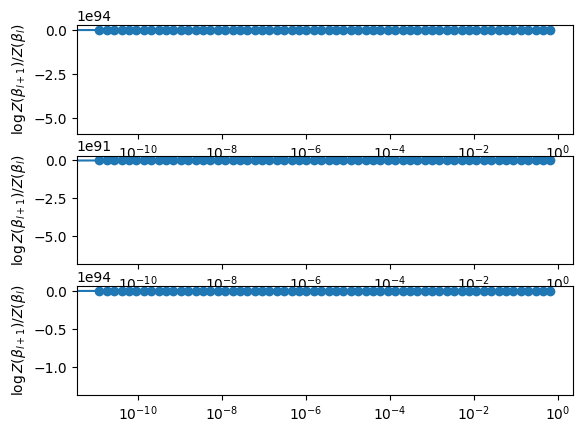

In [85]:
fig, axes = plt.subplots(nrows=3)

for i, run in enumerate(runs):
    res = run.exchange_result

    axes[i].plot(
        res.beta[:-1],
        np.gradient(res.beta)[1:] * run.evidence.log_ratios,
        marker="o",
    )
    axes[i].semilogx()
    axes[i].set_ylabel(r"$\log Z(\beta_{l+1})/Z(\beta_l)$")
axes[0].set_xlabel(r"$\beta_l$")

In [86]:
for l_index in range(result.beta.size - 1):
    delta_beta = result.beta[l_index + 1] - result.beta[l_index]

    log_likelihoods = np.asarray(
        result.log_likelihood_trace_by_temperature[l_index],
        dtype=float,
    )

    log_weights = delta_beta * log_likelihoods

    print(
        f"l: {l_index}, min: {np.min(log_weights):.2f}, max: {np.max(log_weights):.2f}, std: {np.std(log_weights):.2f}"
    )

l: 0, min: -7275860567460249336917465393917857790690563928978276130725811635373927236598852170130518339761899307008.00, max: -7185050373281730479930542688376209791452471576839500197904158089233824320472763476755162932937796616192.00, std: 21688695184807639741552967985247185228315224678223401902616242533735327005665140924497955229402136576.00
l: 1, min: -2.80, max: -0.00, std: 0.34
l: 2, min: -3.24, max: -0.00, std: 0.35
l: 3, min: -2.71, max: -0.00, std: 0.40
l: 4, min: -4.04, max: -0.00, std: 0.43
l: 5, min: -3.05, max: -0.00, std: 0.43
l: 6, min: -2.73, max: -0.00, std: 0.40
l: 7, min: -2.58, max: -0.00, std: 0.42
l: 8, min: -3.23, max: -0.00, std: 0.41
l: 9, min: -3.45, max: -0.00, std: 0.35
l: 10, min: -2.46, max: -0.00, std: 0.33
l: 11, min: -3.78, max: -0.00, std: 0.55
l: 12, min: -3.46, max: -0.00, std: 0.43
l: 13, min: -2.55, max: -0.00, std: 0.49
l: 14, min: -5.25, max: -0.00, std: 0.62
l: 15, min: -3.19, max: -0.00, std: 0.49
l: 16, min: -3.05, max: -0.00, std: 0.62
l: 17, mi

Text(0, 0.5, '$E_\\beta[\\log L]$')

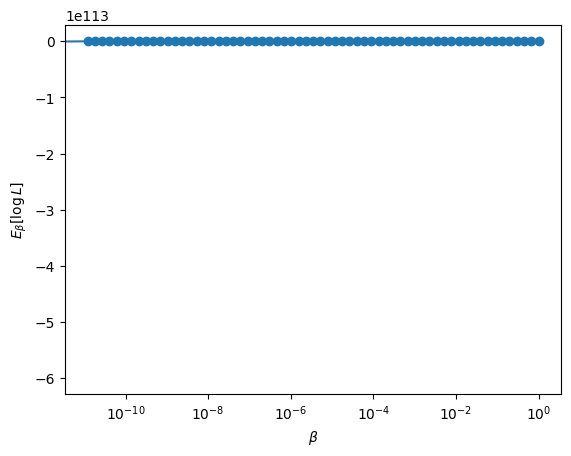

In [87]:
mean_log_likelihood = np.array(
    [np.mean(trace) for trace in result.log_likelihood_trace_by_temperature]
)

plt.plot(result.beta, mean_log_likelihood, marker="o")
plt.semilogx()
plt.xlabel(r"$\beta$")
plt.ylabel(r"$E_\beta[\log L]$")

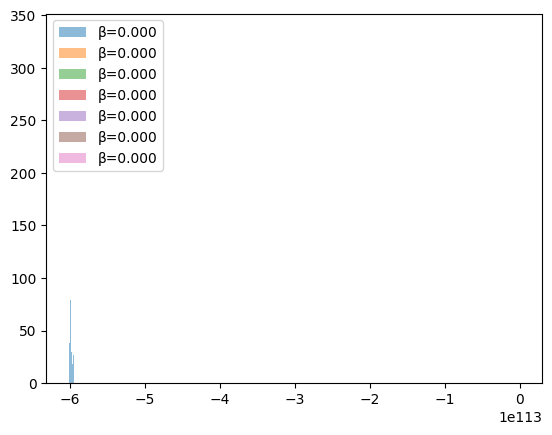

In [88]:
indices = [0, 5, 10, 15, 20, 25, 30]
for i in indices:
    plt.hist(
        result.log_likelihood_trace_by_temperature[i],
        bins=30,
        alpha=0.5,
        label=f"β={result.beta[i]:.3f}",
    )

plt.legend()

Text(0, 0.5, '$\\mathrm{Var}_\\beta(\\log L)$')

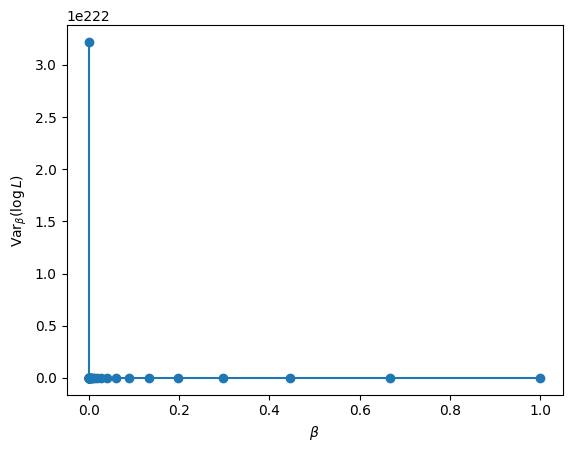

In [89]:
logL_var = np.array(
    [np.var(trace) for trace in result.log_likelihood_trace_by_temperature]
)

plt.plot(result.beta, logL_var, marker="o")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\mathrm{Var}_\beta(\log L)$")